<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
[LibLinear]              precision    recall  f1-score   support

           0       0.88      0.73      0.80       201
           1       0.61      0.80      0.70       107

    accuracy                           0.76       308
   macro av

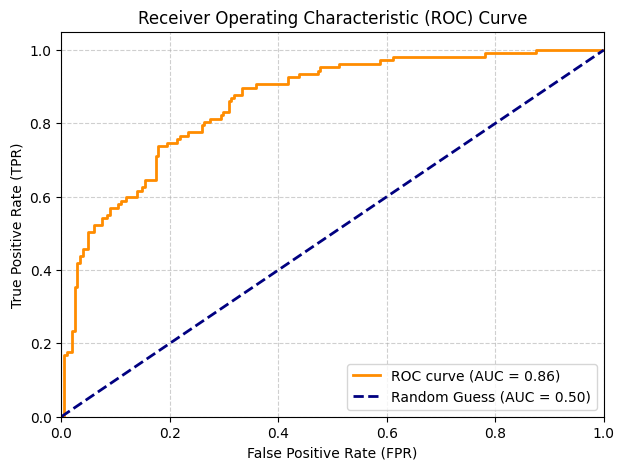

In [74]:
import  pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('diabetes.csv')
df.info()
df.isna().sum()
df.describe()

# we can see that Glucose,BloodPressure,SkinThickness,Insulin,BMI are zero 
# so we will re replacing this with NAN and the applying the imputation

df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]

df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]= df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

X= df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']]
y = df['Outcome']

df['Outcome'].value_counts()
df_num_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin','BMI', 'DiabetesPedigreeFunction', 'Age']

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,PowerTransformer,StandardScaler
from sklearn.metrics import confusion_matrix,log_loss,classification_report,roc_auc_score,roc_curve
from sklearn.linear_model import LogisticRegression
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.40, random_state=43, stratify=y)

tranform_column= Pipeline(steps =[('missing', SimpleImputer(strategy='median',missing_values=np.nan)),
    																														('Scale',PowerTransformer(method='yeo-johnson'))
                                 ])

preprocess = ColumnTransformer(transformers=[('nums',tranform_column, df_num_columns)],remainder='passthrough')

model = Pipeline(steps=[('preprocess',preprocess),
                        ('log',LogisticRegression(class_weight='balanced', solver='liblinear',verbose=True, 
																								n_jobs=-1,penalty='l1',random_state=43))])

model.fit(X_train,y_train)

y_pred= model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(model.score(X_test,y_test))
print(roc_auc_score(y_pred,y_test))
print(roc_curve(y_pred,y_test))


import matplotlib.pyplot as plt
from sklearn.metrics import auc, roc_curve

# NOTE: Always ensure 'y_prob' contains the predicted probabilities 
# generated from model.predict_proba(X_test)[:, 1]

# 1. Compute False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 2. Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# 3. Print the explicit arrays requested
print("False Positive Rates (FPR):", fpr)
print("True Positive Rates (TPR):", tpr)
print("Thresholds:", thresholds)
print("AUC Score:", roc_auc)

# 4. Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Guess (AUC = 0.50)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()
